# 0. Prepration

In [1]:
!rm -rf /kaggle/working/*

In [2]:
!pip install split-folders[full]

In [3]:
import numpy as np
import pandas as pd

# 1. Dataset Split

In [ ]:
import splitfolders

input_folder='/kaggle/input/indian-sign-language-isl/Indian'
output_folder='output'

splitfolders.ratio(input_folder, output=output_folder,
    seed=1337, ratio=(.8, .1, .1), group_prefix=None, move=False) # default values

Copying files: 28483 files [04:00, 195.49 files/s]

# 2. Dataset Loading

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
image_directory="/kaggle/working/output/"#specify the image directory
image_size=(128,128) #global image dimension

train_generator=keras.utils.image_dataset_from_directory(
    image_directory+"train/",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=image_size,
    shuffle=True,
    seed=None,
    validation_split=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

validation_generator=keras.utils.image_dataset_from_directory(
    image_directory+"val/",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(image_dimension,image_dimension),
    shuffle=True,
    seed=None,
    validation_split=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

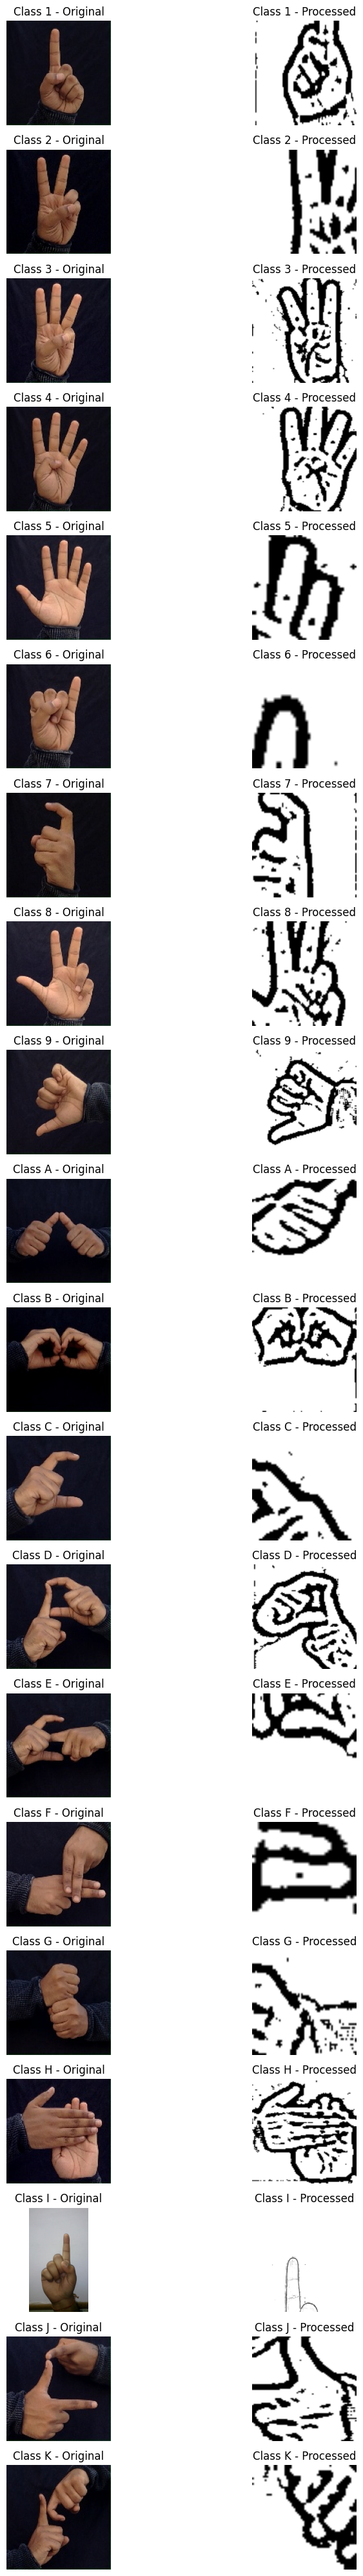

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from torchvision import transforms
from PIL import Image
import random

# Define the custom edge enhancement function (as provided)
def edge_enhancement(img):
    """
    Custom function to perform edge enhancement using OpenCV.
    Args:
        img: PIL Image
    Returns:
        PIL Image with enhanced edges
    """
    # Convert PIL Image to NumPy array
    img_np = np.array(img)

    # Convert to grayscale
    if len(img_np.shape) == 3:  
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(img_np, (5, 5), 2)

    # Apply adaptive thresholding
    thresholded = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    # Apply Otsu's thresholding
    _, processed = cv2.threshold(
        thresholded, 70, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Convert back to PIL Image
    processed_pil = Image.fromarray(processed)

    # Convert back to 3 channels if original was color
    if len(img_np.shape) == 3:
        processed_pil = processed_pil.convert("RGB")

    return processed_pil

# Define the image size
image_size = 128

# Define the preprocessing pipeline as specified
image_transform = transforms.Compose([
    transforms.Lambda(edge_enhancement),  
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

def visualize_samples(dataset_path, num_classes=20):
    # Get all class folders
    class_folders = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    # Select the first num_classes classes
    selected_classes = class_folders[:min(num_classes, len(class_folders))]
    
    # Set seed for reproducibility with random transforms
    torch.manual_seed(42)
    random.seed(42)
    
    # Create a figure for display
    fig, axes = plt.subplots(len(selected_classes), 2, figsize=(10, len(selected_classes) * 2))
    
    for i, class_name in enumerate(selected_classes):
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if image_files:
            # Select a random sample from this class
            img_file = random.choice(image_files)
            img_path = os.path.join(class_path, img_file)
            
            # Load original image
            original_img = Image.open(img_path).convert('RGB')
            
            # Apply the preprocessing to a copy
            processed_tensor = image_transform(original_img.copy())
            
            # Convert original to tensor for display
            original_tensor = transforms.ToTensor()(original_img)
            
            # Display original image
            axes[i, 0].imshow(original_tensor.permute(1, 2, 0))
            axes[i, 0].set_title(f"Class {class_name} - Original")
            axes[i, 0].axis('off')
            
            # Display processed image
            axes[i, 1].imshow(processed_tensor.permute(1, 2, 0))
            axes[i, 1].set_title(f"Class {class_name} - Processed")
            axes[i, 1].axis('off')
        else:
            # Handle empty class folder
            axes[i, 0].text(0.5, 0.5, f"No images in class {class_name}", ha='center', va='center')
            axes[i, 0].axis('off')
            axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Call the function with the path to your dataset
visualize_samples("/kaggle/input/indian-sign-language-isl/Indian/", num_classes=20)


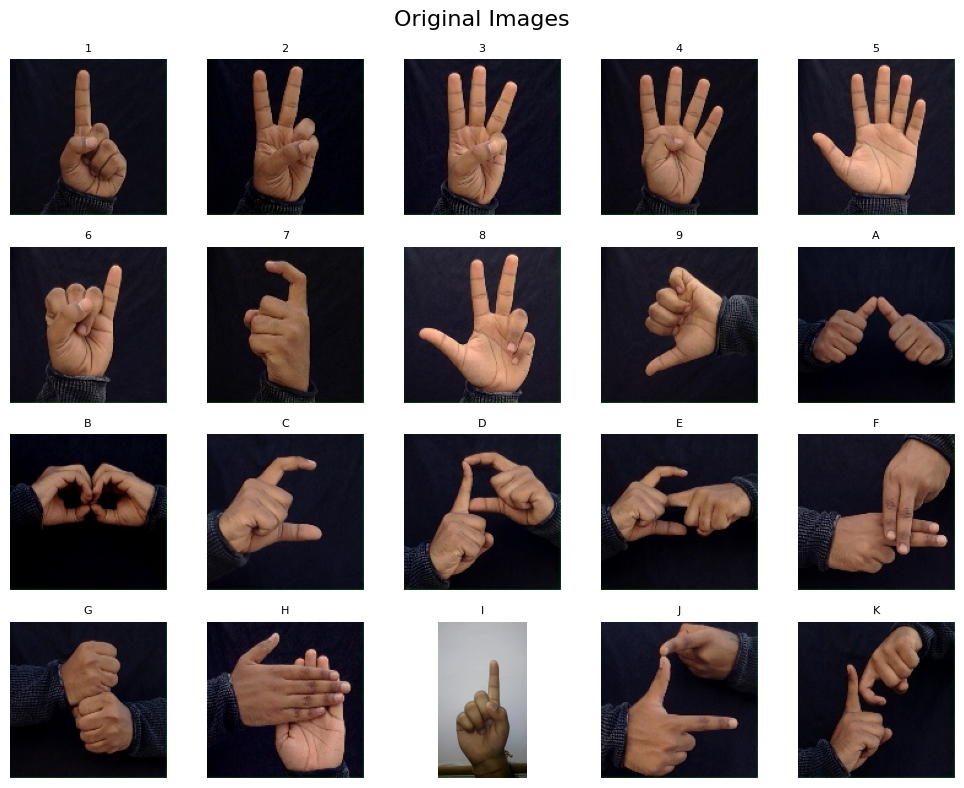

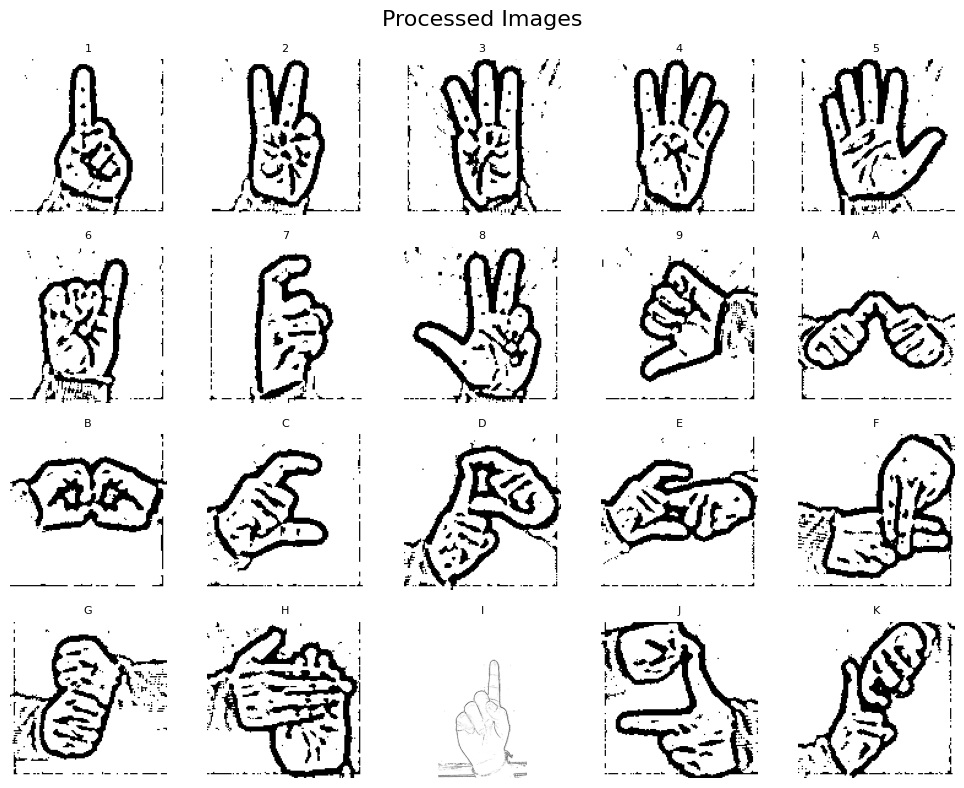

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from torchvision import transforms
from PIL import Image
import random


# --- Your edge_enhancement and image_transform as defined above ---
def edge_enhancement(img):
    """
    Custom function to perform edge enhancement using OpenCV.
    Args:
        img: PIL Image
    Returns:
        PIL Image with enhanced edges
    """
    # Convert PIL Image to NumPy array
    img_np = np.array(img)

    # Convert to grayscale
    if len(img_np.shape) == 3:  
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(img_np, (5, 5), 2)

    # Apply adaptive thresholding
    thresholded = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    # Apply Otsu's thresholding
    _, processed = cv2.threshold(
        thresholded, 70, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Convert back to PIL Image
    processed_pil = Image.fromarray(processed)

    # # Convert back to 3 channels
    if len(img_np.shape) == 3:
        processed_pil = processed_pil.convert("RGB")

    return processed_pil

image_transform = transforms.Compose(
    [
        transforms.Lambda(edge_enhancement),  
        transforms.Grayscale(num_output_channels=3),
        # transforms.RandomResizedCrop(128),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)


def get_samples(dataset_path, num_classes=20):
    class_folders = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    selected_classes = class_folders[:min(num_classes, len(class_folders))]
    orig_images = []
    proc_images = []
    class_names = []
    torch.manual_seed(42)
    random.seed(42)
    for class_name in selected_classes:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            img_file = random.choice(image_files)
            img_path = os.path.join(class_path, img_file)
            original_img = Image.open(img_path).convert('RGB')
            processed_tensor = image_transform(original_img.copy())
            orig_images.append(transforms.ToTensor()(original_img))
            proc_images.append(processed_tensor)
            class_names.append(class_name)
    return orig_images, proc_images, class_names

def plot_image_grid(images, class_names, title, ncols=5, image_size=128):
    n_images = len(images)
    nrows = int(np.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    for idx, ax in enumerate(axes.flat):
        if idx < n_images:
            img = images[idx]
            # if tensor, convert to numpy for display
            if isinstance(img, torch.Tensor):
                img = img.permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(class_names[idx], fontsize=8)
        ax.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# --- Main usage ---
dataset_path = "/kaggle/input/indian-sign-language-isl/Indian"
num_classes = 20
orig_images, proc_images, class_names = get_samples(dataset_path, num_classes)

plot_image_grid(orig_images, class_names, "Original Images", ncols=5)
plot_image_grid(proc_images, class_names, "Processed Images", ncols=5)
